# Fase 1 — Análise Descritiva: Candidatos 2026 (TSE)

Esta fase é **exploração pura**: olhar para os dados de candidatos e de bens declarados sem nenhum compromisso com o que vem depois (clusterização, regras de associação, anomalias). A ideia é conhecer o dataset por conta própria — distribuições, proporções, outliers, relações entre variáveis — **antes** de qualquer modelo apontar o que "importa". As fases seguintes vão te pedir pra escolher variáveis; essa escolha deve nascer do que você observar aqui, não o contrário.

Este notebook parte do arquivo salvo pela **Fase 0** (`00_preparacao_dados.ipynb`).

## Configuração

Use os **mesmos valores** que você usou na Fase 0, para carregar o arquivo certo.

In [1]:
CARGO = "SENADOR"
UF = None
ANO_ELEICAO = 2026

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:,.2f}".format)

nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo = f"dados/candidatos_{nome_cargo}_{nome_uf}_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

Carregado: dados/candidatos_SENADOR_BRASIL_2026.csv  ->  313 candidatos, 61 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE,VR_DESPESA_CONTRATADA,VR_DESPESA_CONTRATADA_log
0,21/09/2026,19:31:26,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,5,SENADOR,10002533895,100,CYLMARA FERNANDES DA ROCHA GRIPP,MARA ROCHA,#NULO,41186273291,NÃO DIVULGÁVEL,-3,#NE,COLIGAÇÃO,10,REPUBLICANOS,REPUBLICANOS,-1,#NULO,#NULO,#NULO,10001800117,TRABALHO DA ESPERANÇA,REPUBLICANOS / PSD / AVANTE / NOVO,AC,1973-09-04,2324422437,4,FEMININO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,171,JORNALISTA E REDATOR,-1,#NULO,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,53.00,"730,480.46",13.50
1,21/09/2026,19:31:26,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,5,SENADOR,10002535804,555,SERGIO DE OLIVEIRA CUNHA,PETECÃO,#NULO,9604332287,NÃO DIVULGÁVEL,-3,#NE,COLIGAÇÃO,55,PSD,PARTIDO SOCIAL DEMOCRÁTICO,-1,#NULO,#NULO,#NULO,10001800117,TRABALHO DA ESPERANÇA,REPUBLICANOS / PSD / AVANTE / NOVO,AC,1960-04-20,825962445,2,MASCULINO,6,ENSINO MÉDIO COMPLETO,3,CASADO(A),3,PARDA,257,EMPRESÁRIO,-1,#NULO,"2,328,619.58","1,085,051.00",0.00,"44,810.00",0.00,"403,114.28","3,861,594.86",15.17,66.00,"1,042,358.50",13.86
2,21/09/2026,19:31:26,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,5,SENADOR,10002536441,131,JORGE NEY VIANA MACEDO NEVES,JORGE VIANA,#NULO,96980486853,NÃO DIVULGÁVEL,-3,#NE,COLIGAÇÃO,13,PT,PARTIDO DOS TRABALHADORES,101,FEDERAÇÃO BRASIL DA ESPERANÇA - FE BRASIL,13-PT/65-PC do B/43-PV,13-PT/65-PC do B/43-PV,10001800264,FRENTE AMPLA PELO ACRE,PODE / PSB / FEDERAÇÃO BRASIL DA ESPERANÇA - F...,AC,1959-09-20,780342402,2,MASCULINO,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),3,PARDA,101,ENGENHEIRO,-1,#NULO,"4,699,419.72",0.00,"41,923.19","154,880.55","159,441.62","520,126.80","5,575,791.88",15.53,67.00,"1,371,032.27",14.13
3,21/09/2026,19:31:26,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,5,SENADOR,10002536710,277,RIBAMAR DE SOUSA FEITOZA JÚNIOR,DR. JUNIOR FEITOSA,#NULO,67146902234,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,27,DC,DEMOCRACIA CRISTÃ,-1,#NULO,#NULO,#NULO,10001800309,PARTIDO ISOLADO,DC,AC,1982-05-09,3576712402,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),3,PARDA,131,ADVOGADO,-1,#NULO,0.00,"464,000.00",0.00,0.00,0.00,"888,418.21","1,352,418.21",14.12,44.00,0.00,0.00
4,21/09/2026,19:31:26,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,5,SENADOR,10002544110,500,INACIO ALVES MOREIRA NETTO,PROFESSOR INACIO MOREIRA,#NULO,32218893215,NÃO DIVULGÁVEL,-3,#NE,FEDERAÇÃO,50,PSOL,PARTIDO SOCIALISMO E LIBERDADE,102,FEDERAÇÃO PSOL REDE,50-PSOL/18-REDE,50-PSOL/18-REDE,10001800655,FEDERAÇÃO,FEDERAÇÃO PSOL REDE (50-PSOL / 18-REDE),AC,1970-05-14,1440942429,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),2,PRETA,265,PROFESSOR DE ENSINO FUNDAMENTAL,-1,#NULO,"200,000.00",0.00,0.00,0.00,0.00,0.00,"200,000.00",12.21,56.00,"32,585.97",10.39


## 1) Visão geral: tamanho, tipos e dados ausentes

Antes de olhar variável por variável, um raio-x da tabela inteira.

313 candidatos x 61 colunas



,nº de colunas
object,31
int64,19
float64,11


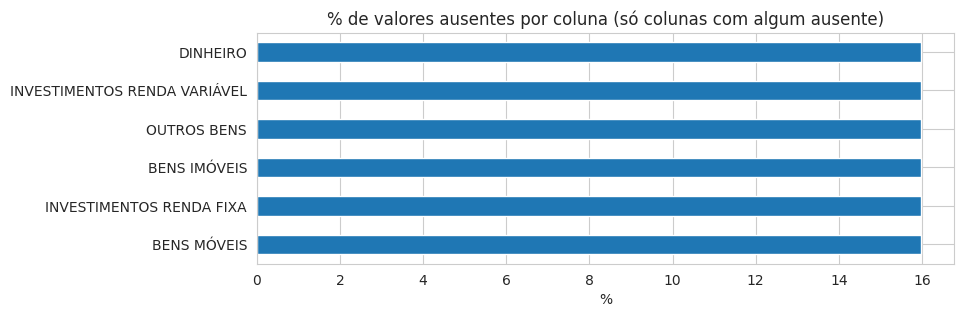

In [3]:
print(f"{df.shape[0]} candidatos x {df.shape[1]} colunas\n")
display(df.dtypes.value_counts().rename('nº de colunas'))

faltantes = (df.isna().mean() * 100).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]

if len(faltantes) > 0:
    plt.figure(figsize=(9, max(3, len(faltantes) * 0.3)))
    faltantes.plot(kind='barh')
    plt.title('% de valores ausentes por coluna (só colunas com algum ausente)')
    plt.xlabel('%')
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Nenhuma coluna com valores ausentes.")

## 2) Escolhendo o que explorar

O dataset tem dezenas de colunas — muitas são identificadores administrativos (`SQ_CANDIDATO`, `NR_CPF_CANDIDATO`, `DS_EMAIL`, hashes de geração...) sem valor analítico. As duas listas abaixo reúnem as colunas com conteúdo substantivo — **sintam-se livres para adicionar outras que despertarem curiosidade** (`df.columns` mostra tudo o que está disponível).

In [4]:
display(pd.DataFrame({"Coluna": df.columns}))

,Coluna
0,DT_GERACAO
1,HH_GERACAO
2,ANO_ELEICAO
3,CD_TIPO_ELEICAO
4,NM_TIPO_ELEICAO
...,...
56,Total_Bens
57,Total_Bens_Log
58,IDADE
59,VR_DESPESA_CONTRATADA


In [5]:
colunas_numericas = [
    'IDADE',
    'Total_Bens',
    'Total_Bens_Log',
    'BENS MÓVEIS',
    'BENS IMÓVEIS',
    'DINHEIRO',
    'INVESTIMENTOS RENDA FIXA',
    'INVESTIMENTOS RENDA VARIÁVEL',
    'OUTROS BENS',
    'VR_DESPESA_CONTRATADA',
    'VR_DESPESA_CONTRATADA_log'
]
colunas_numericas = [c for c in colunas_numericas if c in df.columns]

colunas_categoricas = [
    'DS_GENERO',
    'DS_ESTADO_CIVIL',
    'DS_COR_RACA',
    'DS_GRAU_INSTRUCAO',
    'DS_SITUACAO_CANDIDATURA',
    'DS_SIT_TOT_TURNO',
    'TP_AGREMIACAO',
    'SG_PARTIDO',
    'DS_OCUPACAO',
    'NR_TURNO',
    'SG_UE',
]
colunas_categoricas = [c for c in colunas_categoricas if c in df.columns]

print("Numéricas:")
display(pd.DataFrame({"Coluna": colunas_numericas}))
print("Categóricas:")
display(pd.DataFrame({"Coluna": colunas_categoricas}))

Numéricas:


,Coluna
0,IDADE
1,Total_Bens
2,Total_Bens_Log
3,BENS MÓVEIS
4,BENS IMÓVEIS
5,DINHEIRO
6,INVESTIMENTOS RENDA FIXA
7,INVESTIMENTOS RENDA VARIÁVEL
8,OUTROS BENS
9,VR_DESPESA_CONTRATADA


Categóricas:


,Coluna
0,DS_GENERO
1,DS_ESTADO_CIVIL
2,DS_COR_RACA
3,DS_GRAU_INSTRUCAO
4,DS_SITUACAO_CANDIDATURA
5,DS_SIT_TOT_TURNO
6,TP_AGREMIACAO
7,SG_PARTIDO
8,DS_OCUPACAO
9,NR_TURNO


## 3) Variáveis numéricas: distribuição e outliers

In [6]:
display(df[colunas_numericas].describe().T)

,count,mean,std,min,25%,50%,75%,max
IDADE,313.00,55.53,11.25,35.00,46.00,56.00,64.00,92.00
Total_Bens,313.00,"6,637,180.00","42,015,295.21",0.00,"102,129.76","665,000.00","2,403,414.92","613,221,297.87"
Total_Bens_Log,313.00,11.57,5.38,0.00,11.53,13.41,14.69,20.23
BENS MÓVEIS,263.00,"305,243.76","1,635,067.31",0.00,0.00,"36,290.00","197,500.00","25,463,113.27"
BENS IMÓVEIS,263.00,"2,400,311.27","21,604,112.83",0.00,"47,900.00","364,000.00","1,232,500.00","350,000,000.00"
DINHEIRO,263.00,"280,436.48","3,094,925.66",0.00,0.00,0.00,"28,928.62","50,000,000.00"
INVESTIMENTOS RENDA FIXA,263.00,"357,776.15","1,885,982.36",0.00,0.00,0.00,"53,353.54","26,545,287.52"
INVESTIMENTOS RENDA VARIÁVEL,263.00,"1,155,018.40","9,638,402.07",0.00,0.00,0.00,"25,587.00","145,249,279.24"
OUTROS BENS,263.00,"3,400,215.22","29,326,272.44",0.00,0.00,"13,879.44","539,161.90","466,773,083.57"
VR_DESPESA_CONTRATADA,313.00,"989,309.17","1,215,688.32",0.00,"6,355.24","167,748.80","1,840,325.29","4,842,635.70"


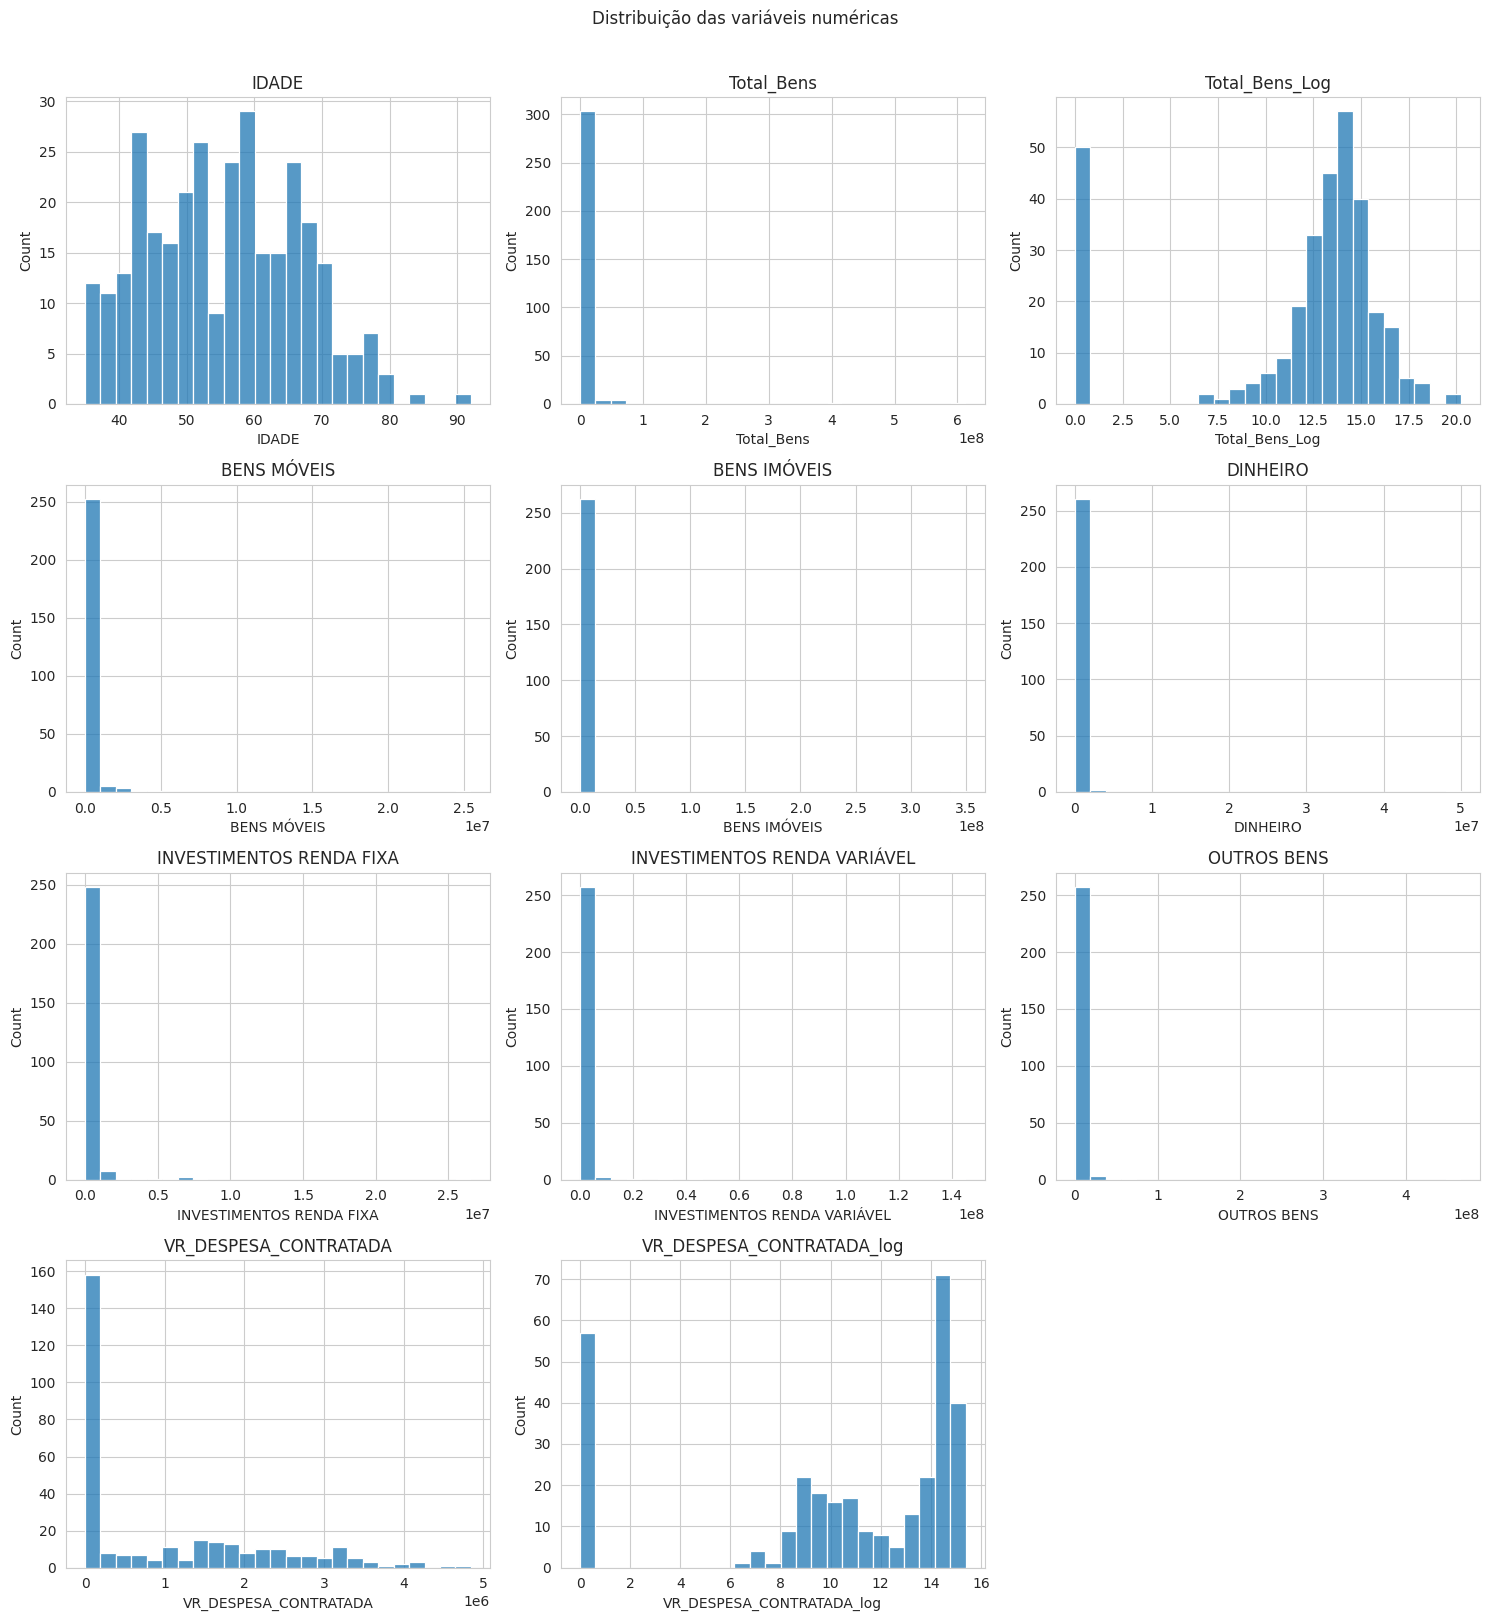

In [7]:
n = len(colunas_numericas)
ncols = 3
nrows = -(-n // ncols)  # arredonda pra cima

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.histplot(df[col], bins=25, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das variáveis numéricas', y=1.01)
plt.tight_layout()
plt.show()

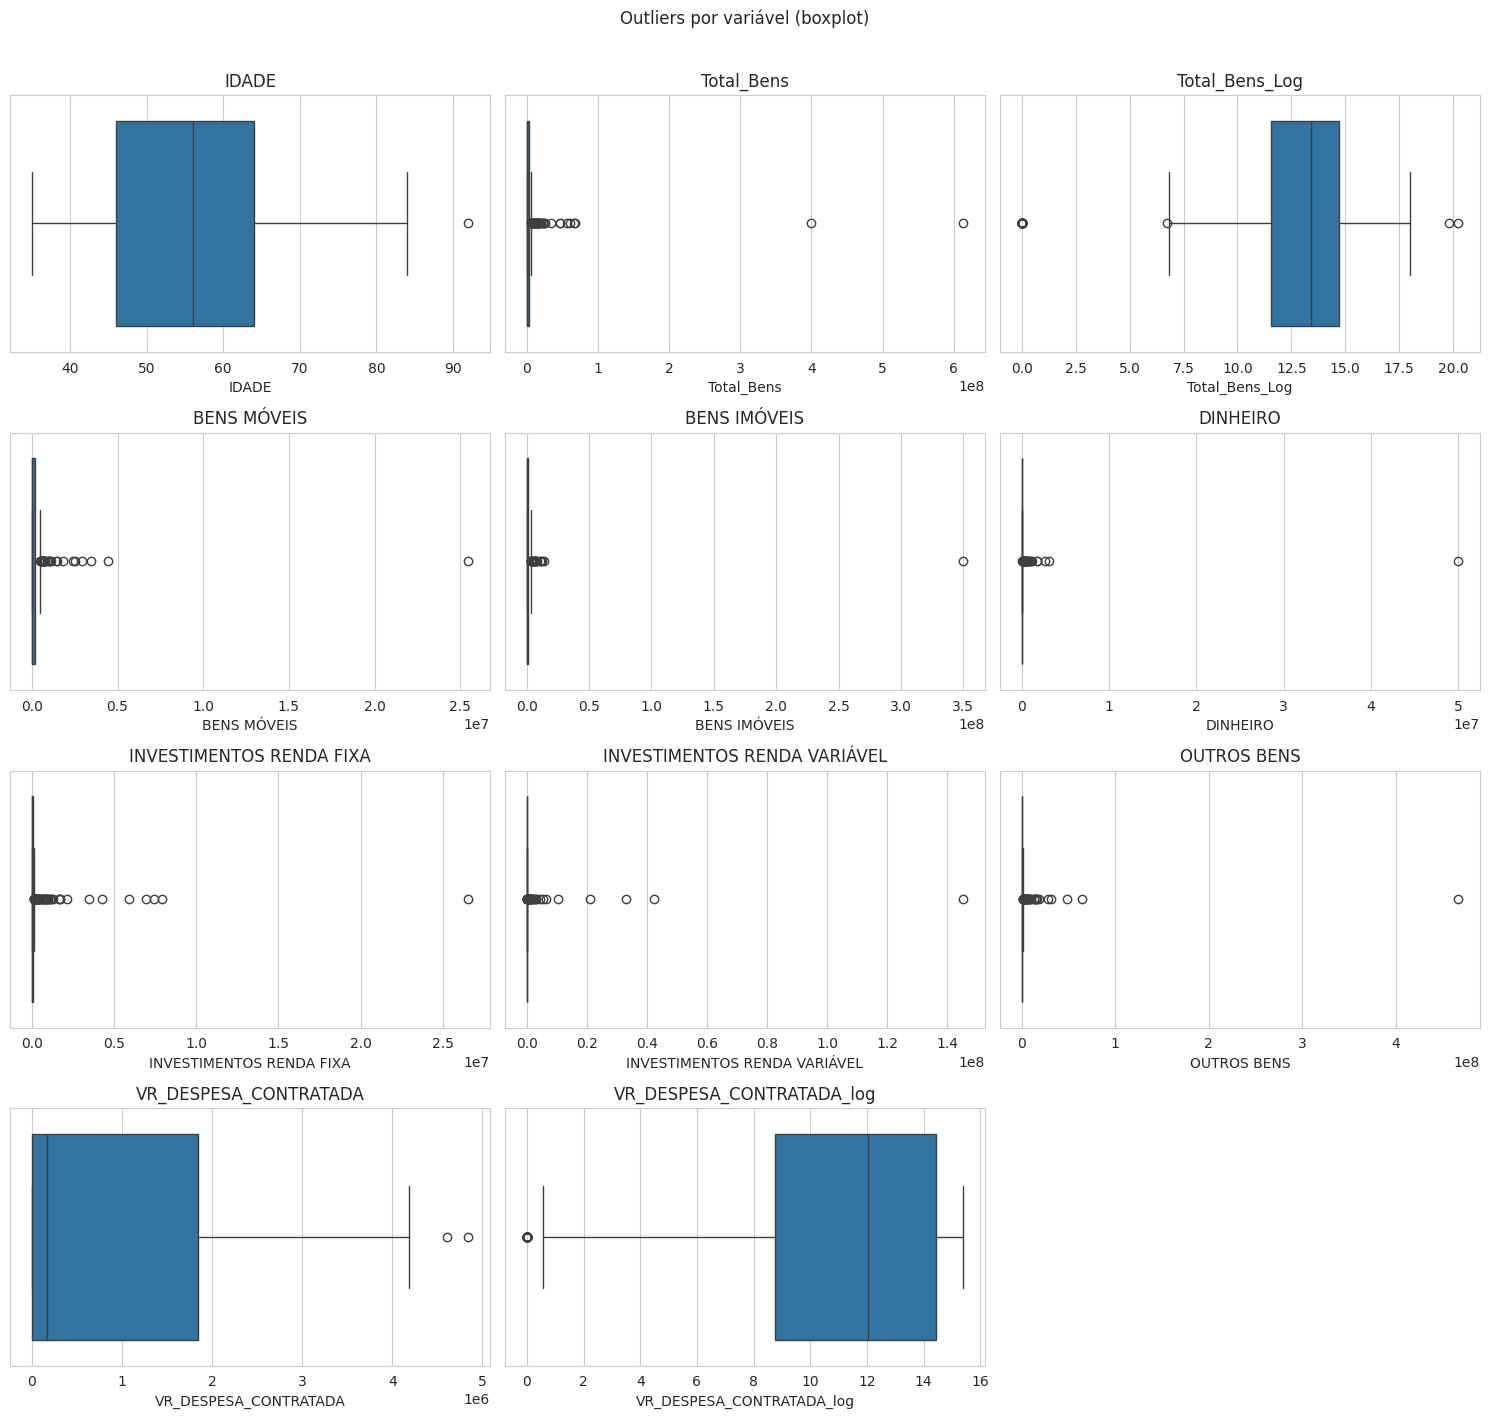

In [8]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outliers por variável (boxplot)', y=1.01)
plt.tight_layout()
plt.show()

### 3.1) Quantificando os outliers (regra do IQR)

O boxplot mostra visualmente; esta tabela quantifica: quantos candidatos ficam fora do intervalo `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]` em cada variável.

In [9]:
linhas = []
for col in colunas_numericas:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    linhas.append({
        'variavel': col, 'limite_inferior': lim_inf, 'limite_superior': lim_sup,
        'qtd_outliers': n_outliers, 'pct_outliers': round(100 * n_outliers / len(df), 1),
    })

pd.DataFrame(linhas).sort_values('pct_outliers', ascending=False)

,variavel,limite_inferior,limite_superior,qtd_outliers,pct_outliers
7,INVESTIMENTOS RENDA VARIÁVEL,"-38,380.50","63,967.50",60,19.20
10,VR_DESPESA_CONTRATADA_log,0.25,22.93,56,17.90
6,INVESTIMENTOS RENDA FIXA,"-80,030.32","133,383.86",54,17.30
2,Total_Bens_Log,6.80,19.43,53,16.90
5,DINHEIRO,"-43,392.94","72,321.56",49,15.70
8,OUTROS BENS,"-808,742.85","1,347,904.75",39,12.50
1,Total_Bens,"-3,349,797.98","5,855,342.66",38,12.10
3,BENS MÓVEIS,"-296,250.00","493,750.00",32,10.20
4,BENS IMÓVEIS,"-1,729,000.00","3,009,400.00",20,6.40
9,VR_DESPESA_CONTRATADA,"-2,744,599.83","4,591,280.37",2,0.60


## 4) Variáveis categóricas: contagens e proporções

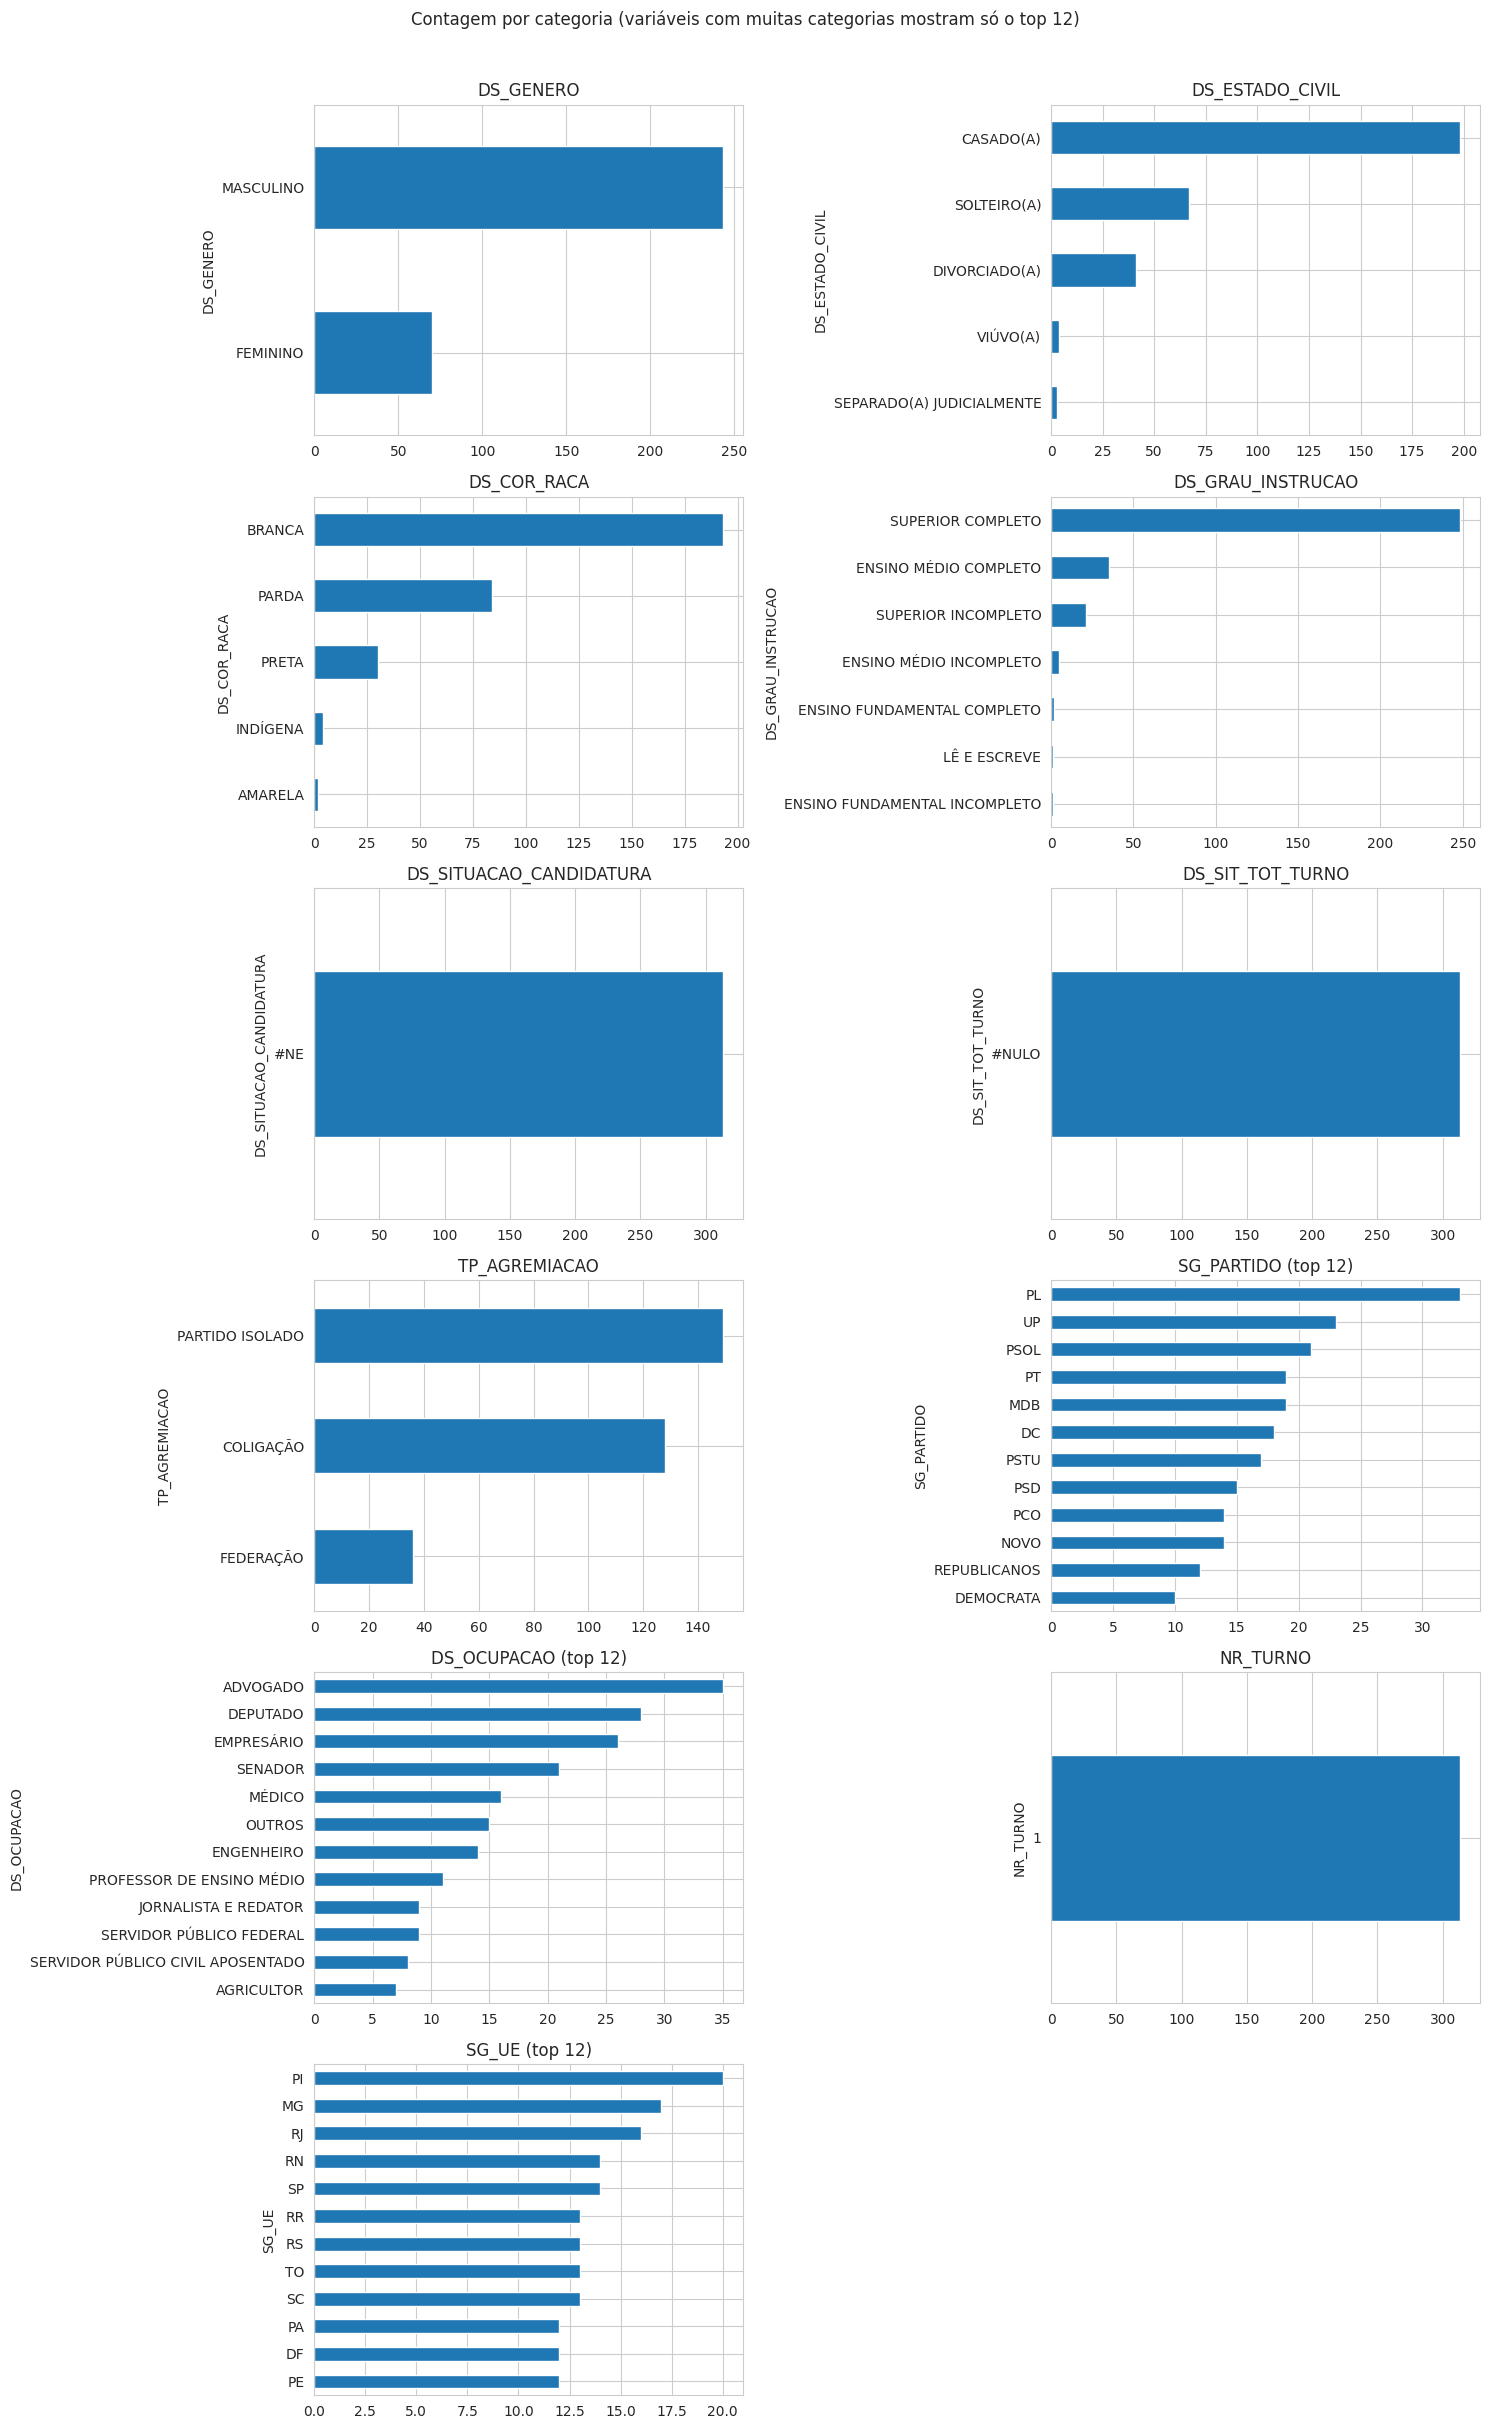

In [10]:
def plot_categorica(ax, coluna, top_n=12):
    contagem = df[coluna].value_counts().head(top_n)
    contagem.plot(kind='barh', ax=ax)
    ax.set_title(coluna + (f' (top {top_n})' if df[coluna].nunique() > top_n else ''))
    ax.invert_yaxis()

n = len(colunas_categoricas)
ncols = 2
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    plot_categorica(axes[i], col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Contagem por categoria (variáveis com muitas categorias mostram só o top 12)', y=1.01)
plt.tight_layout()
plt.show()

In [11]:
for col in colunas_categoricas:
    print(f"--- {col} ({df[col].nunique()} categorias) ---")
    print((df[col].value_counts(normalize=True).head(8) * 100).round(1).astype(str) + '%')
    print()

--- DS_GENERO (2 categorias) ---
DS_GENERO
MASCULINO    77.6%
FEMININO     22.4%
Name: proportion, dtype: object

--- DS_ESTADO_CIVIL (5 categorias) ---
DS_ESTADO_CIVIL
CASADO(A)                    63.3%
SOLTEIRO(A)                  21.4%
DIVORCIADO(A)                13.1%
VIÚVO(A)                      1.3%
SEPARADO(A) JUDICIALMENTE     1.0%
Name: proportion, dtype: object

--- DS_COR_RACA (5 categorias) ---
DS_COR_RACA
BRANCA      61.7%
PARDA       26.8%
PRETA        9.6%
INDÍGENA     1.3%
AMARELA      0.6%
Name: proportion, dtype: object

--- DS_GRAU_INSTRUCAO (7 categorias) ---
DS_GRAU_INSTRUCAO
SUPERIOR COMPLETO                79.2%
ENSINO MÉDIO COMPLETO            11.2%
SUPERIOR INCOMPLETO               6.7%
ENSINO MÉDIO INCOMPLETO           1.6%
ENSINO FUNDAMENTAL COMPLETO       0.6%
LÊ E ESCREVE                      0.3%
ENSINO FUNDAMENTAL INCOMPLETO     0.3%
Name: proportion, dtype: object

--- DS_SITUACAO_CANDIDATURA (1 categorias) ---
DS_SITUACAO_CANDIDATURA
#NE    100.0%
Nam

## 5) Dispersão entre variáveis numéricas

Correlação e gráficos de dispersão par a par — sem nenhuma variável de destaque, só pra ver como as variáveis se relacionam (ou não).

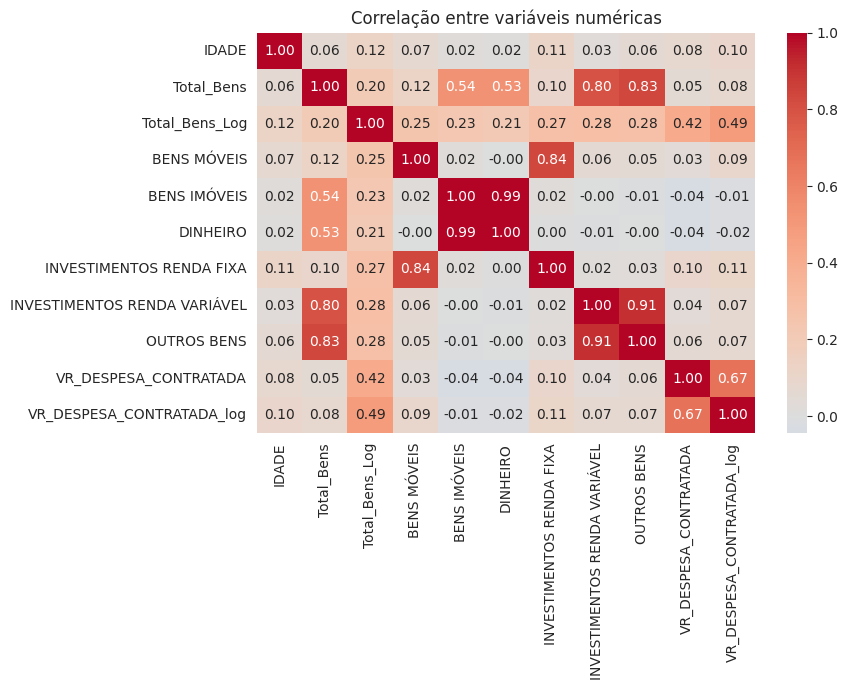

In [12]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[colunas_numericas].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

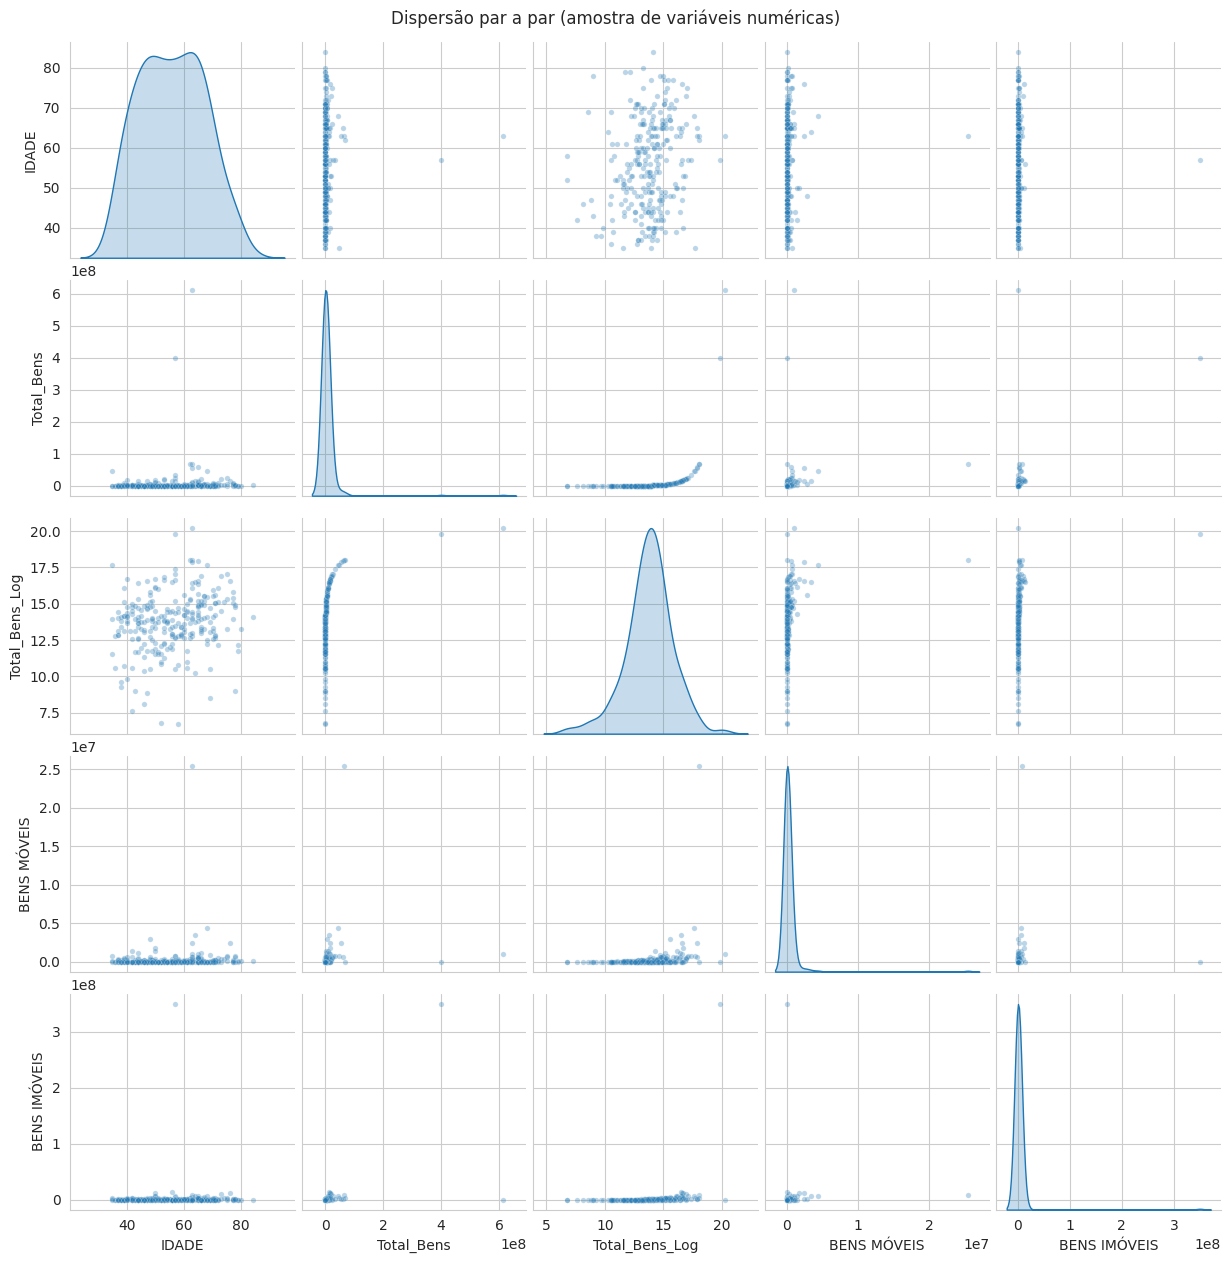

In [13]:
# Pairplot com um subconjunto (pairplot com muitas variáveis fica pesado/ilegível)
subset = colunas_numericas[:5]
sns.pairplot(df[subset].dropna(), diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15})
plt.suptitle('Dispersão par a par (amostra de variáveis numéricas)', y=1.01)
plt.show()

### 5.1) Um exemplo de dispersão colorida

Só um exemplo de como cruzar uma variável numérica com outra numérica *e* uma categórica ao mesmo tempo — troquem `x`, `y` e `hue` livremente para explorar outras combinações.

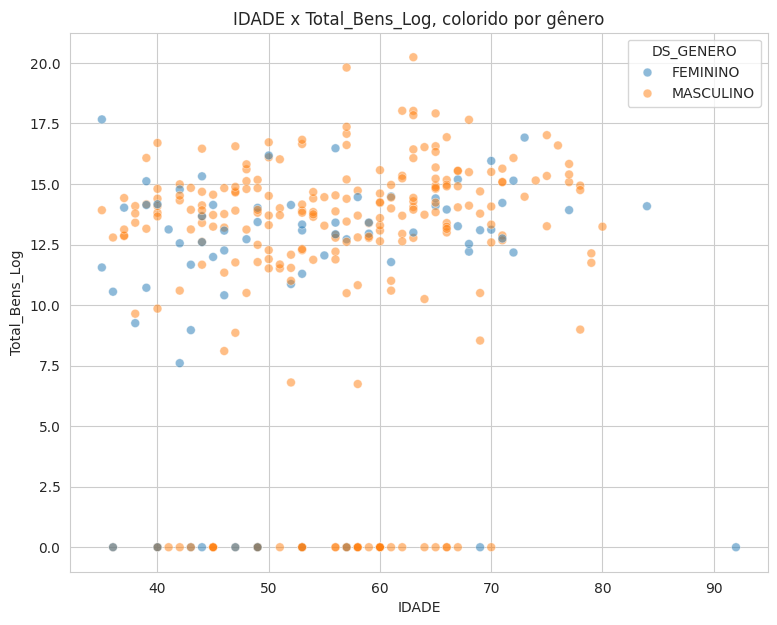

In [14]:
plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x='IDADE', y='Total_Bens_Log', hue='DS_GENERO', alpha=0.5, s=40)
plt.title('IDADE x Total_Bens_Log, colorido por gênero')
plt.show()

## 6) Proporções entre grupos

Alguns exemplos de cruzamentos categóricos — não são os únicos possíveis, só uma amostra do tipo de pergunta que dá pra fazer.

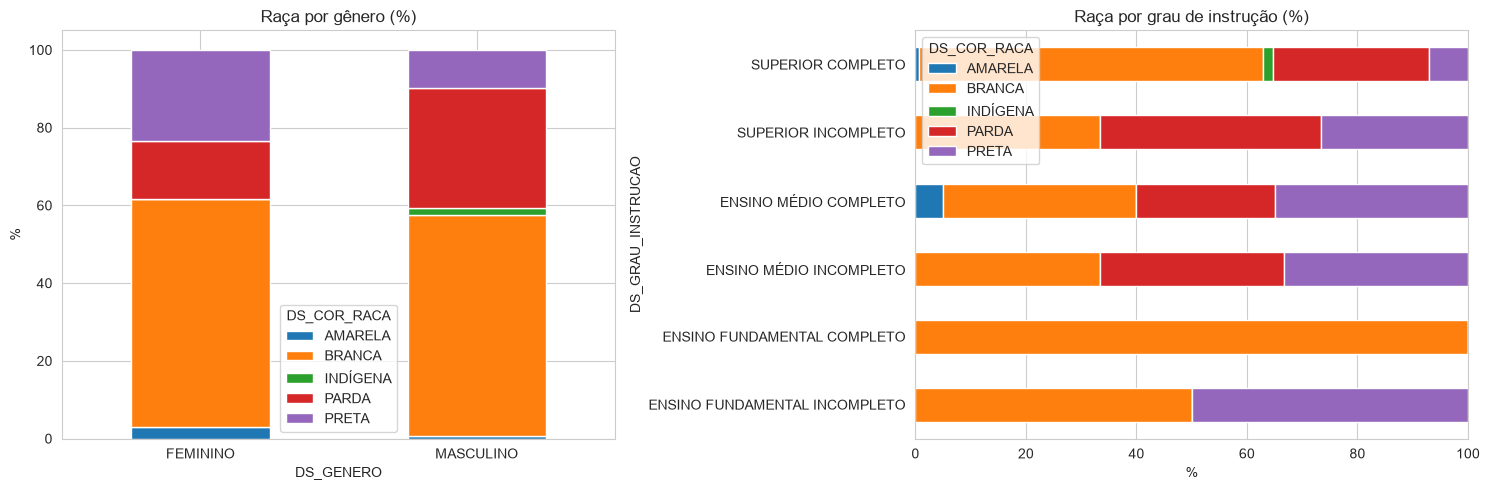

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pd.crosstab(df['DS_GENERO'], df['DS_COR_RACA'], normalize='index').mul(100).plot(
    kind='bar', stacked=True, ax=axes[0]
)
axes[0].set_title('Raça por gênero (%)')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)

ordem_instrucao = df[['CD_GRAU_INSTRUCAO', 'DS_GRAU_INSTRUCAO']].drop_duplicates().sort_values('CD_GRAU_INSTRUCAO')['DS_GRAU_INSTRUCAO']
pd.crosstab(df['DS_GRAU_INSTRUCAO'], df['DS_COR_RACA'], normalize='index').loc[ordem_instrucao].mul(100).plot(
    kind='barh', stacked=True, ax=axes[1]
)
axes[1].set_title('Raça por grau de instrução (%)')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.show()

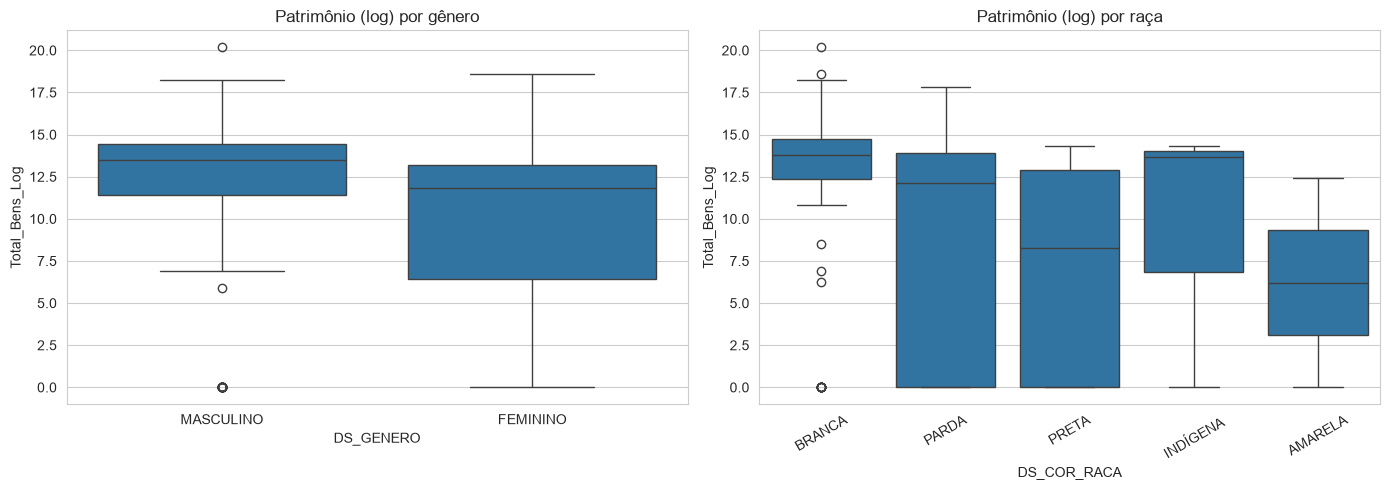

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='DS_GENERO', y='Total_Bens_Log', ax=axes[0])
axes[0].set_title('Patrimônio (log) por gênero')

sns.boxplot(data=df, x='DS_COR_RACA', y='Total_Bens_Log', ax=axes[1])
axes[1].set_title('Patrimônio (log) por raça')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

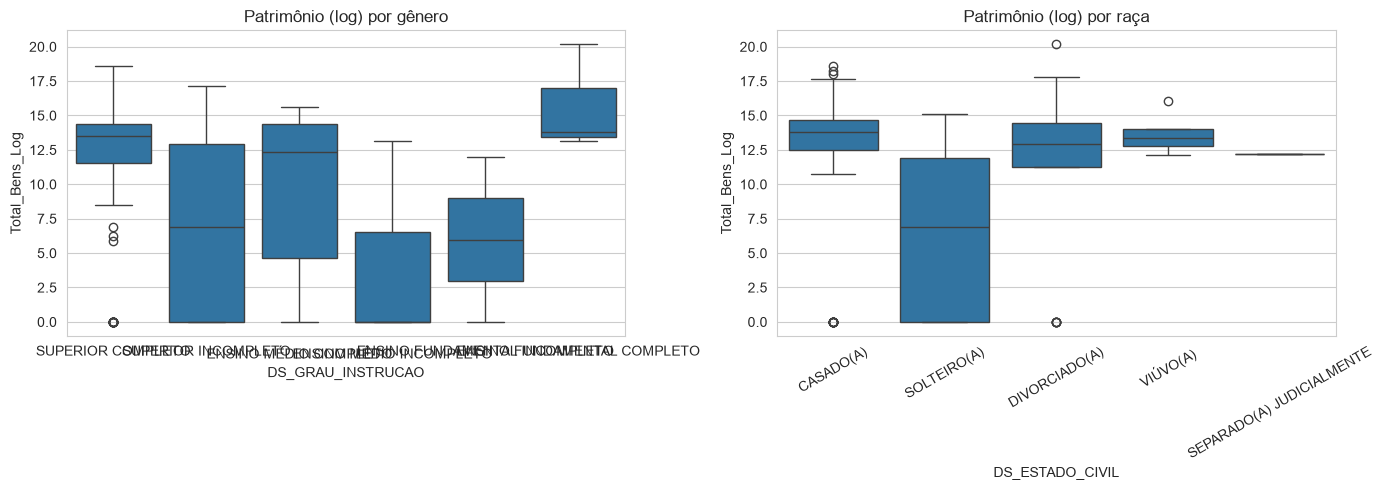

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='DS_GRAU_INSTRUCAO', y='Total_Bens_Log', ax=axes[0])
axes[0].set_title('Patrimônio (log) por gênero')

sns.boxplot(data=df, x='DS_ESTADO_CIVIL', y='Total_Bens_Log', ax=axes[1])
axes[1].set_title('Patrimônio (log) por raça')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

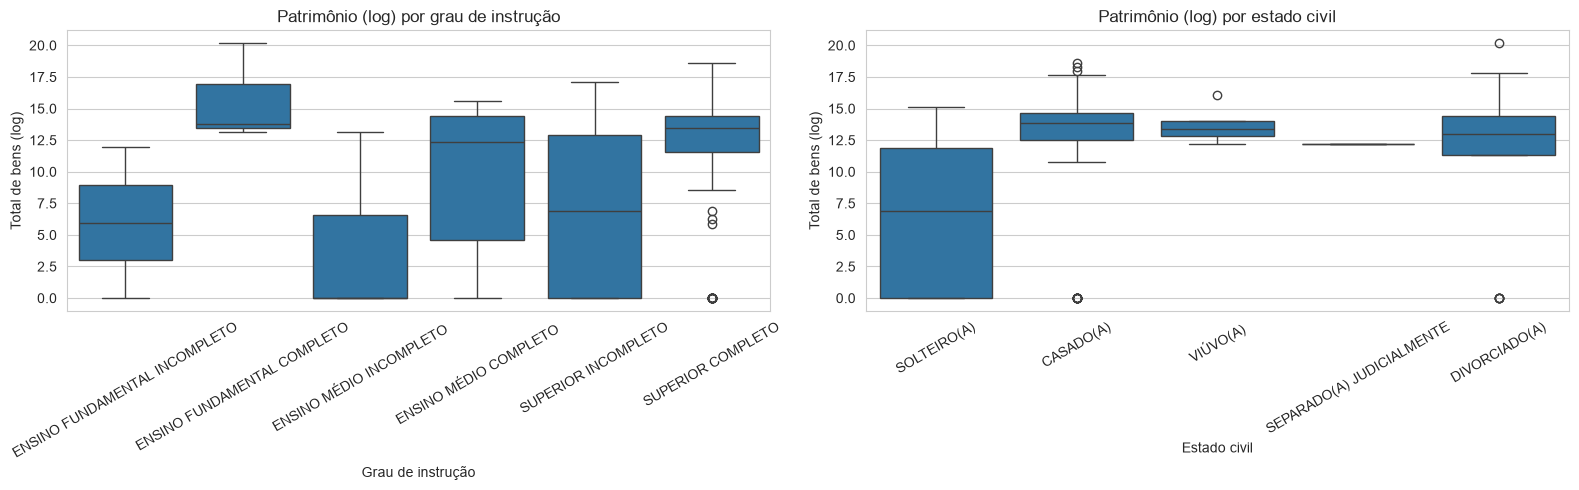

In [ ]:
# Ordem do grau de instrução pelo respectivo código
ordem_instrucao = (
    df[['CD_GRAU_INSTRUCAO', 'DS_GRAU_INSTRUCAO']]
    .drop_duplicates()
    .sort_values('CD_GRAU_INSTRUCAO')
    ['DS_GRAU_INSTRUCAO']
    .tolist()
)

# Ordem do estado civil pelo respectivo código
ordem_estado_civil = (
    df[['CD_ESTADO_CIVIL', 'DS_ESTADO_CIVIL']]
    .drop_duplicates()
    .sort_values('CD_ESTADO_CIVIL')
    ['DS_ESTADO_CIVIL']
    .tolist()
)


# Cria os dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# Grau de instrução
sns.boxplot(
    data=df,
    x='DS_GRAU_INSTRUCAO',
    y='Total_Bens_Log',
    order=ordem_instrucao,
    ax=axes[0]
)

axes[0].set_title('Patrimônio (log) por grau de instrução')
axes[0].set_xlabel('Grau de instrução')
axes[0].set_ylabel('Total de bens (log)')
axes[0].tick_params(axis='x', rotation=30)


# Estado civil
sns.boxplot(
    data=df,
    x='DS_ESTADO_CIVIL',
    y='Total_Bens_Log',
    order=ordem_estado_civil,
    ax=axes[1]
)

axes[1].set_title('Patrimônio (log) por estado civil')
axes[1].set_xlabel('Estado civil')
axes[1].set_ylabel('Total de bens (log)')
axes[1].tick_params(axis='x', rotation=30)


plt.tight_layout()
plt.show()

## 7) Comparação entre UFs

Esta seção só roda na visão **Brasil** (quando `UF = None`) — não se aplica ao recorte por estado.

,qtd_candidatos,idade_media,patrimonio_mediano,pct_feminino
SG_UF,,,,
PI,12,55.20,"624,567.30",25.00
DF,11,51.40,"830,171.00",27.30
MG,11,48.40,"956,564.00",9.10
CE,9,46.20,"157,000.00",11.10
RN,9,54.00,"228,000.00",11.10
RJ,9,46.40,"189,210.60",11.10
PE,8,43.50,"192,500.00",25.00
SC,8,50.60,"1,039,776.90",12.50
MA,8,48.90,"852,660.20",0.00


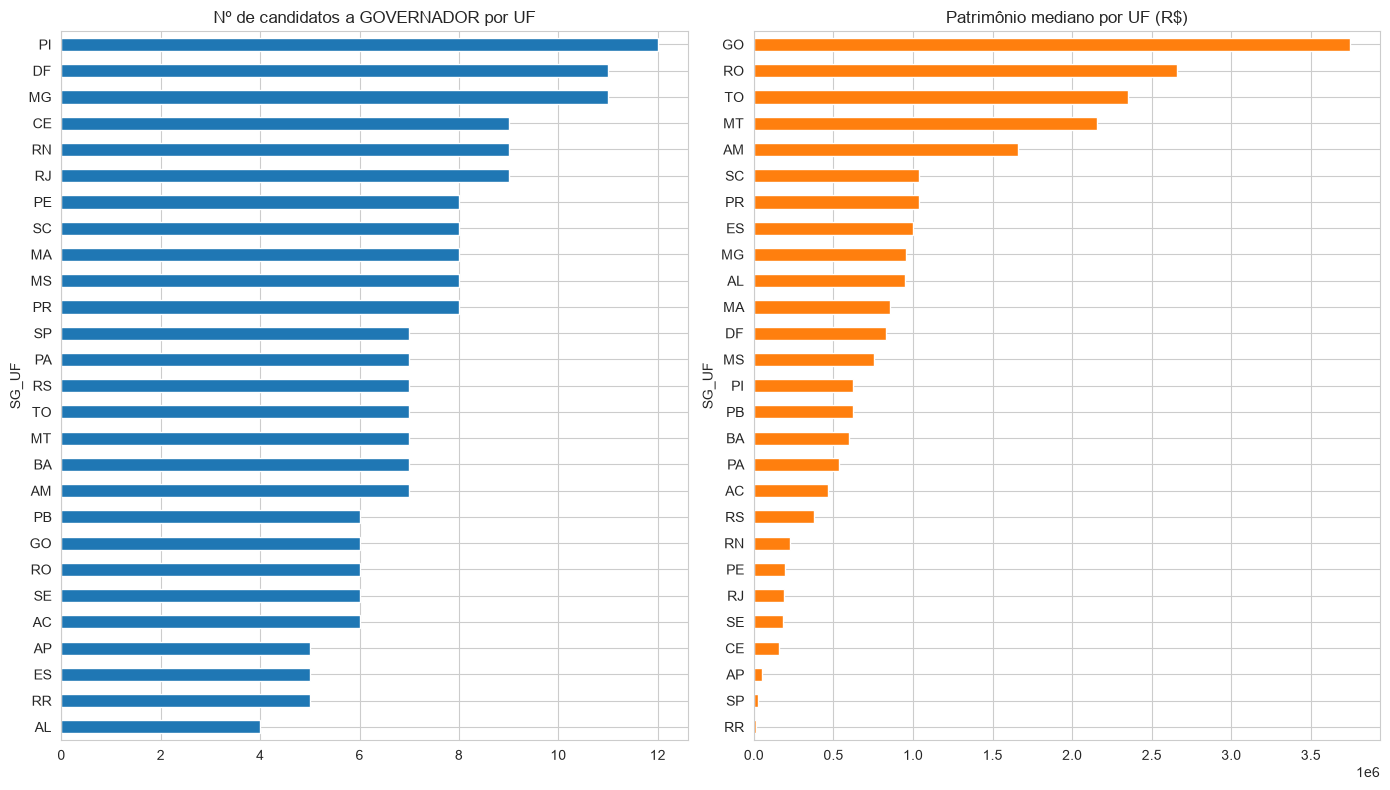

In [ ]:
if UF is None:
    resumo_uf = df.groupby('SG_UF').agg(
        qtd_candidatos=('SQ_CANDIDATO', 'count'),
        idade_media=('IDADE', 'mean'),
        patrimonio_mediano=('Total_Bens', 'median'),
        pct_feminino=('DS_GENERO', lambda x: (x == 'FEMININO').mean() * 100),
    ).round(1).sort_values('qtd_candidatos', ascending=False)

    display(resumo_uf)

    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    resumo_uf['qtd_candidatos'].sort_values().plot(kind='barh', ax=axes[0])
    axes[0].set_title(f'Nº de candidatos a {CARGO} por UF')

    resumo_uf['patrimonio_mediano'].sort_values().plot(kind='barh', ax=axes[1], color='tab:orange')
    axes[1].set_title('Patrimônio mediano por UF (R$)')

    plt.tight_layout()
    plt.show()
else:
    print(f"UF = {UF!r} — seção não se aplica (dados já filtrados para uma única UF).")

---
## Fechamento

Este notebook não teve o objetivo de "preparar terreno" para nenhuma técnica específica — foi só olhar para os dados. Antes de seguir, escrevam algumas observações próprias: quais variáveis têm mais outliers? Alguma proporção chamou atenção? Alguma dispersão sugere relação entre variáveis (ou ausência dela)? Essas observações são o ponto de partida — não a conclusão — das próximas fases.

## Próximo passo

**Fase 2 — Clusterização** (K-Means, DBSCAN, hierárquico e Bisecting K-Means) — liberada em breve. A escolha de variáveis para essa fase parte do que vocês observaram aqui.